In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df_interruptions= pd.read_csv('./data/comments.csv')
df_interruptions.head(5)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,0,So kriegen Sie die Steuerlüge nicht aus der W...,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,2,Das ist doch die erste Lesung!,CDU/CSU,<unknown>,DIE LINKE,Dr. Barbara Höll,1991-03-12,11,2
3,3,Das ist eine Frechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
4,4,Gebt erst mal das Vermögen der PDS dem Staat ...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7


In [10]:
non_string_entries = df_interruptions['comment_text'].apply(lambda x: not isinstance(x, str))
df_interruptions= df_interruptions[~non_string_entries]

In [15]:
print(f"Alle Datensätze: {len(df_interruptions)}")
df_interruptions= df_interruptions.sample(2500)
print(f"Teilmenge: {len(df_interruptions)}")

Alle Datensätze: 467923
Teilmenge: 2500


In [16]:
df_labeled  = pd.read_csv('./data/comments_for_labeling_labeled.csv')
df_labeled.head()

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_id,preceding_context,sentiment
0,433684,Jetzt nicht durcheinanderkommen!,GRÜNE,Dr. Till Steffen,AfD,Dirk Brandes,2023-07-05,194603,DIE LINKE]: Jeder Cent für die Sozialsysteme i...,1
1,238107,Ui!,DIE LINKE,Michael Schlecht,CDU/CSU,Ulrich Lange,2011-06-30,106964,"uwirken. Tun Sie das endlich, (Beifall bei Abg...",0
2,381901,Sie haben es nicht verstanden!,FDP,Dr. Marco Buschmann,GRÜNE,Dr. Manuela Rottmann,2021-01-28,173441,soll das? Sie stärken damit doch nicht den Bun...,1
3,148254,Wir auch!,FDP,Ulrike Flach,CDU/CSU,Dr. Maria Böhmer,2004-12-02,69450,len Leuten Sachen! Damit wäre ich vorsichtig!)...,0
4,61862,"Es ist schon interessant, was da herauskommt!",SPD,Horst Sielaff,FDP,Günther Bredehorn,1998-06-18,39933,"ilosophie „Mengen runter, Preise rauf"" hat sic...",0


In [17]:
df_labeled = df_labeled.drop(range(106,300))

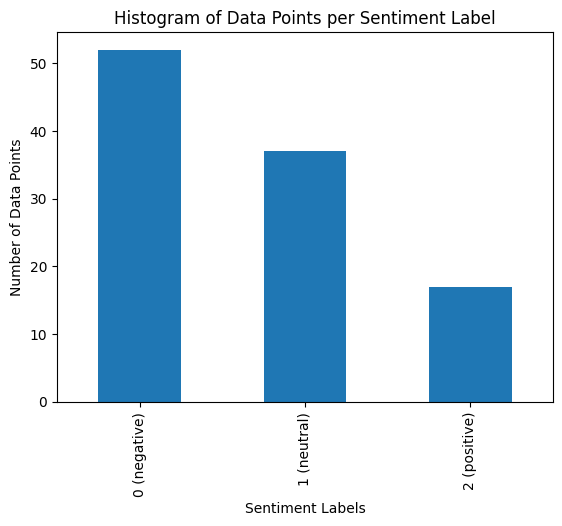

In [20]:
label_counts = df_labeled['sentiment'].value_counts()

# Sentiment mapping
sentiment_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Plotting the histogram
ax = label_counts.plot(kind='bar')
ax.set_xlabel('Sentiment Labels')
ax.set_ylabel('Number of Data Points')
ax.set_title('Histogram of Data Points per Sentiment Label')

# Customizing x-axis labels
ax.set_xticklabels([f'{index} ({sentiment_mapping[index]})' for index in label_counts.index])

plt.show()

In [21]:
from germansentiment import SentimentModel

model = SentimentModel()

texts = [
    "Mit keinem guten Ergebniss","Das ist gar nicht mal so gut",
    "Total awesome!","nicht so schlecht wie erwartet",
    "Der Test verlief positiv.","Sie fährt ein grünes Auto."]
       
result = model.predict_sentiment(texts)
print(result)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Robin\.cache\huggingface\hub\models--oliverguhr--german-sentiment-bert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

['negative', 'negative', 'positive', 'positive', 'neutral', 'neutral']


c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [25]:
preds = model.predict_sentiment(df_labeled['comment_text'])
senti_to_int= {'neutral': 0, 'negative':1, 'positive':2}

df_labeled['result'] = [senti_to_int[s] for s in preds]

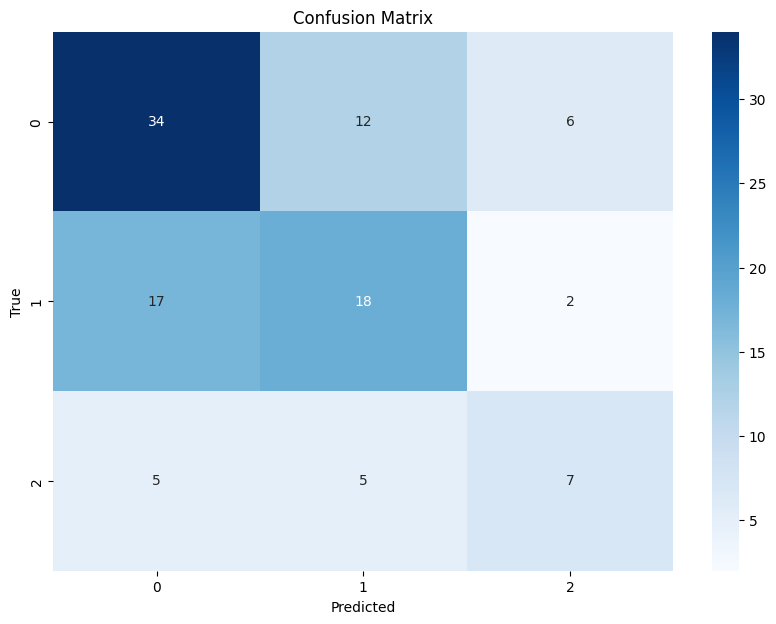

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns



conf_matrix_bert = confusion_matrix(df_labeled['sentiment'], df_labeled['result'])
# plot confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [27]:
from sklearn.metrics import classification_report
print(classification_report(df_labeled['sentiment'], df_labeled['result'], target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.61      0.65      0.63        52
     neutral       0.51      0.49      0.50        37
    positive       0.47      0.41      0.44        17

    accuracy                           0.56       106
   macro avg       0.53      0.52      0.52       106
weighted avg       0.55      0.56      0.55       106

